# **Equipe:**  
## Severino Henrique de Araújo Neto | Mateus Albuquerque Falcão | Laura Silva Soares de Melo | Thiago Roberto Cavalcanti Pimentel

**Data:** Abril de 2026

# Arvores de Decisão - Regressão

## Dicionário dos dados:

Aquisição de dados: Este é os dados de clima para Seattle, WA, em 2016,
usando o instrumento NOAA Climate Data Online.

- year: 2016
- month: número do mês do ano (por exemplo, 7 para julho)
- day: número do dia do ano (por exemplo, 30 para 30 de junho)
- week: dia da semana como uma string de caractere (por exemplo,
"segunda-feira")
- temp_1: temperatura de um dia anterior
- temp_2: temperatura de dois dias anteriores
- average: Média histórica da temperatura máxima
- Previsão do seu amigo (aleatório), valor menor 20 abaixo da média ou 20 acima da média
- actual: Medição de temperatura máxima real

Atividade:
1. Carregamento de dados
2. O valor esperado de saída é **actual**
3. Remover as colunas 'year', 'month', 'day', 'week' pois não vamos considerar dados históricos relacionados a série temporal
4. Análise descritiva dos dados
5. Remoção de campos desnecessários
6. Tratamento de dados nulos e/ou faltantes
7. Separação dos dados, holdout
8. Normalização dos dados
9. Treinamento de modelos

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Obtenha os dados
** Leia o arquivo csv 'temps.csv' em um DataFrame **

In [47]:
path = "C:/Users/melos/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/eng._e_ analise_de_dados/bases/temps - temps.csv"
df = pd.read_csv(path, header=0)

** Verifique o cabeçalho do DataFrame.**

In [48]:
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [50]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


Remoção das colunas year,	month, day e week, pois não vamos trabalhar com a série temporal

In [51]:
df.drop(columns=["year", "month", "day", "week"], inplace=True)

In [52]:
df.head()

,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,45,45,45.6,45,43,50,44,29
1,44,45,45.7,44,41,50,44,61
2,45,44,45.8,41,43,46,47,56
3,44,41,45.9,40,44,48,46,53
4,41,40,46.0,44,46,46,46,41


## Estatística Descritiva

Dados faltantes

<Axes: >

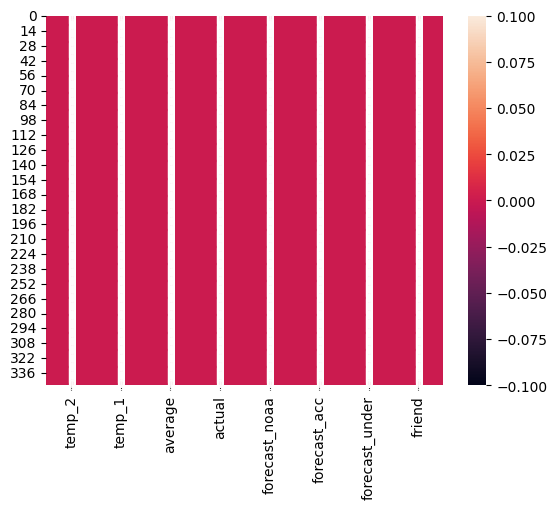

In [53]:
#df.isnull()
#heatmap
sns.heatmap(df.isnull(), annot=True)

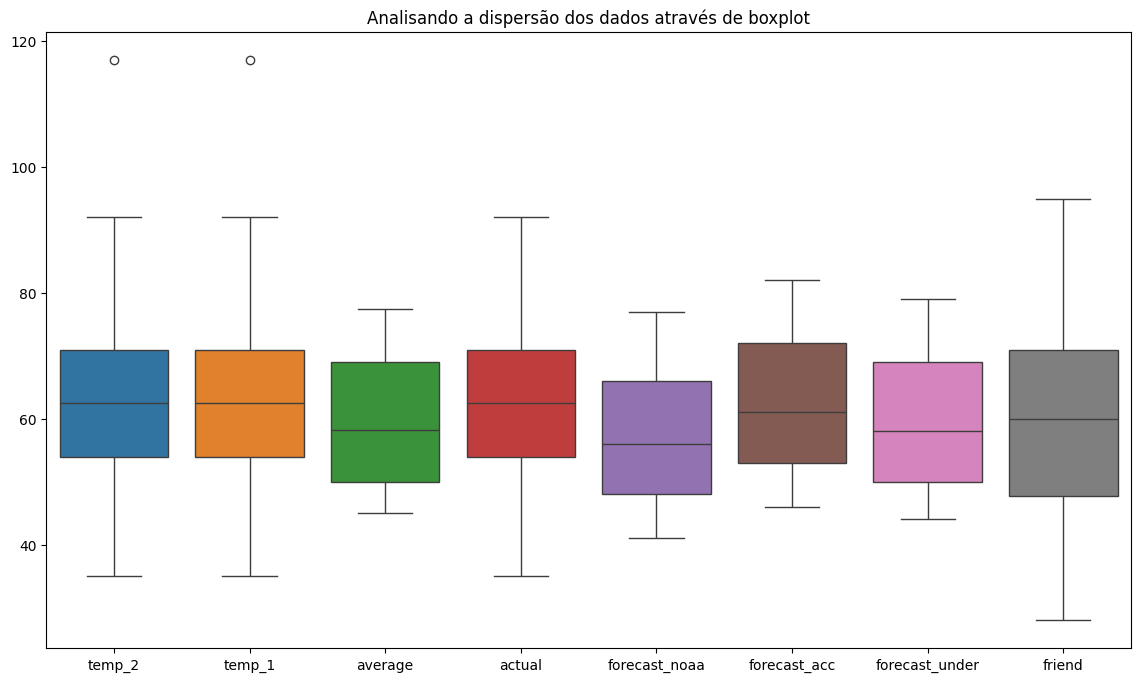

In [54]:
#plot dos valores com boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title('Analisando a dispersão dos dados através de boxplot')
plt.show()

C:\Users\melos\AppData\Local\Temp\ipykernel_936\1325344932.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=False)


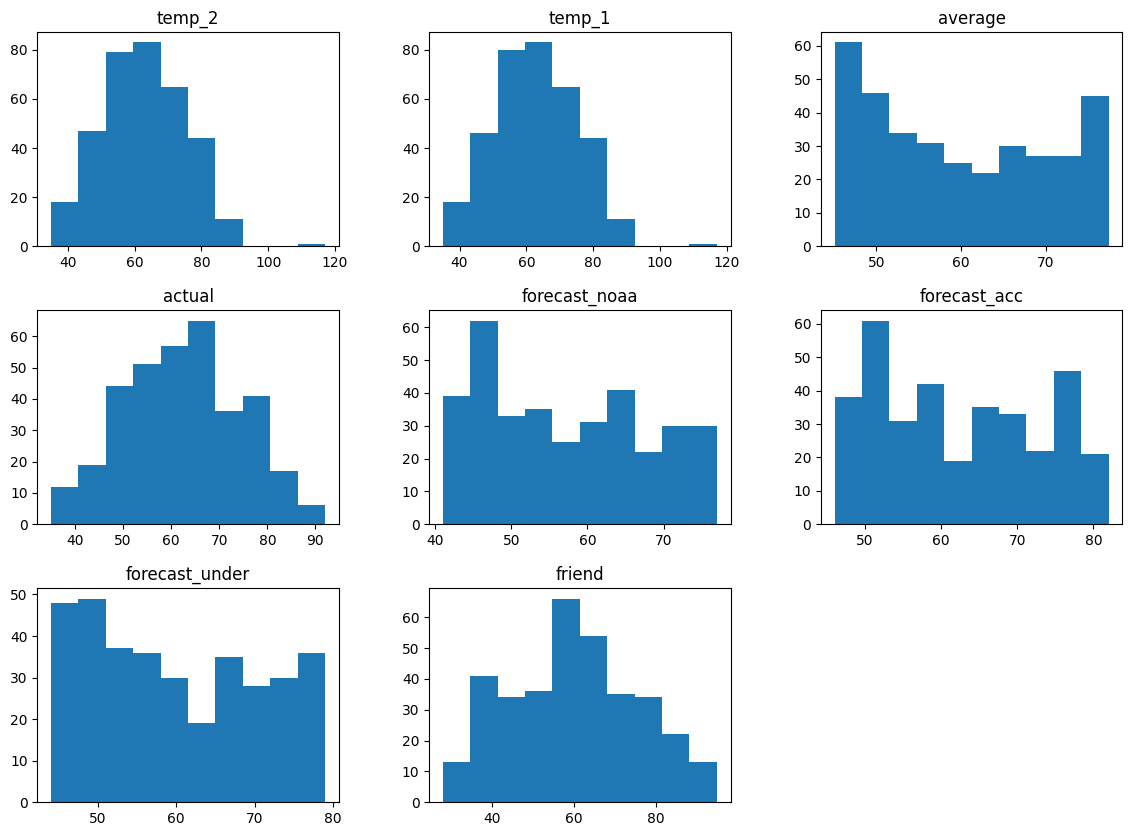

In [55]:
#plot dos valores com histogramas

fig = plt.figure(figsize = (14,10))
ax = fig.gca()
df.hist(ax = ax, grid=False)
plt.title("Dispersão dos dados")
plt.show()

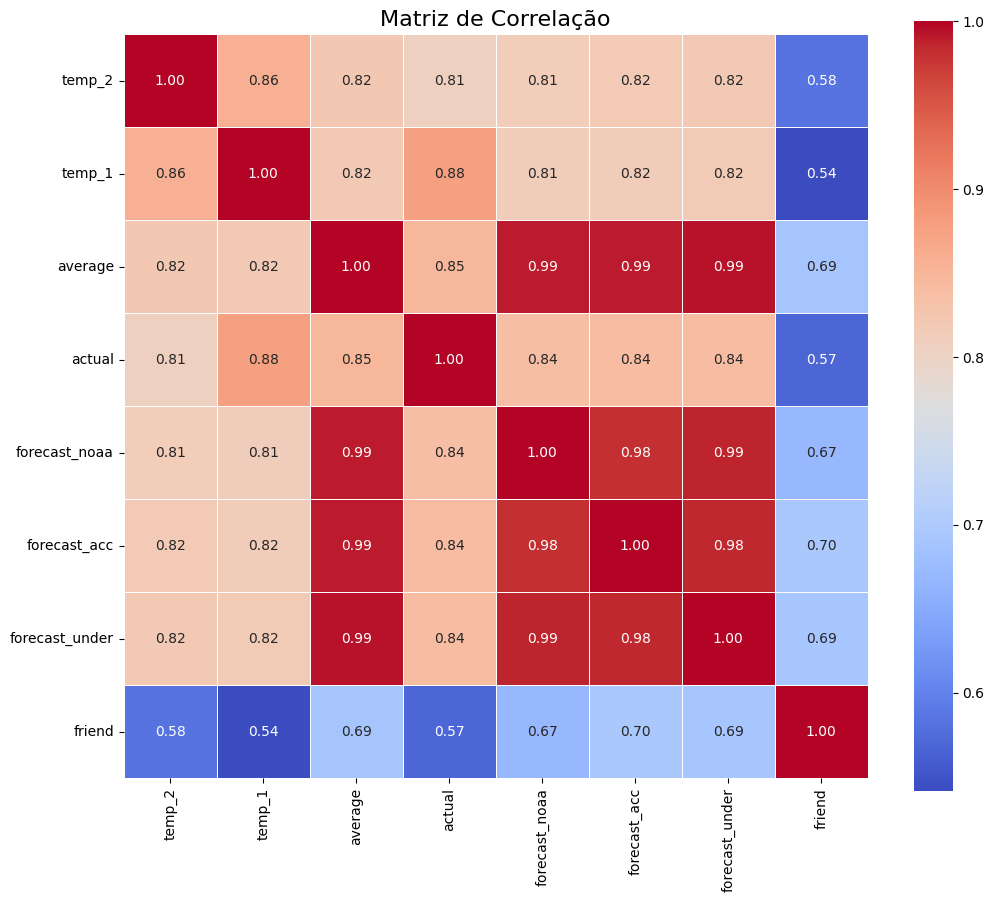

In [56]:
#plot dos valores com matriz de correlação

corr = df.corr()
corr

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=16)
plt.show()

## Separação dos dados, holdout

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['actual']),
                                                    df['actual'],
                                                    test_size=0.25,
                                                    random_state=111)

In [59]:
print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

Tamanho do conjunto de treino: (261, 7)
Tamanho do conjunto de teste: (87, 7)


In [60]:
pd.DataFrame(X_train)

,temp_2,temp_1,average,forecast_noaa,forecast_acc,forecast_under,friend
120,77,87,62.1,62,66,64,69
20,48,52,47.8,43,51,46,57
114,59,60,60.7,59,65,60,50
264,63,64,62.5,60,65,61,73
239,70,74,71.5,71,75,70,82
...,...,...,...,...,...,...,...
169,70,76,70.8,68,75,71,57
275,60,61,58.4,58,60,57,41
86,56,64,55.7,51,57,56,57
212,77,73,77.3,77,81,77,93


## Normalização dos dados

Hora de para padronizar as variáveis.

Import StandardScaler do Scikit-learn.

In [61]:
# Import StandardScaler do Scikit-learn
from sklearn.preprocessing import StandardScaler  

In [62]:
scaler = StandardScaler() 

Converta as variáveis independentes com o StandardScaler

In [63]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [90]:
# Transformando os dados de treino e teste utilizando o mesmo scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("#Dados normalizados#")
print(f"Média do treino normalizado: {X_train_scaled.mean(axis=0)}")
print(f"Desvio padrão do treino normalizado: {X_train_scaled.std(axis=0)}")

#Dados normalizados#
Média do treino normalizado: [ 1.63343158e-16 -6.12536841e-17  2.58626666e-16  1.02089474e-16
  6.80596490e-18 -1.70149123e-16  2.04178947e-16]
Desvio padrão do treino normalizado: [1. 1. 1. 1. 1. 1. 1.]


In [65]:
X_train_scaled[:3]

array([[ 1.17318321,  1.97519864,  0.17908574,  0.40319769,  0.31190317,
         0.35302158,  0.50816738],
       [-1.30444617, -0.92660895, -1.19312058, -1.40462993, -1.1366151 ,
        -1.33932067, -0.26821322],
       [-0.36465572, -0.26333864,  0.04474386,  0.11775122,  0.21533528,
        -0.02305447, -0.72110191]])

In [66]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261 entries, 120 to 340
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp_2          261 non-null    int64  
 1   temp_1          261 non-null    int64  
 2   average         261 non-null    float64
 3   forecast_noaa   261 non-null    int64  
 4   forecast_acc    261 non-null    int64  
 5   forecast_under  261 non-null    int64  
 6   friend          261 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 16.3 KB


In [67]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 49 to 244
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp_2          87 non-null     int64  
 1   temp_1          87 non-null     int64  
 2   average         87 non-null     float64
 3   forecast_noaa   87 non-null     int64  
 4   forecast_acc    87 non-null     int64  
 5   forecast_under  87 non-null     int64  
 6   friend          87 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 5.4 KB


----------------------------------------------------------------------------------------

## Árvores de Decisão

Árvore de Decisão é um modelo que aprende a fazer previsões fazendo perguntas encadeadas sobre os dados, como um fluxograma.

No contexto do exercício (prever temperatura), a árvore funciona assim:

    A temperatura de ontem (temp_1) foi > 50°F?
            |                        |
            SIM                      NÃO
            |                        |
    A média histórica > 55°F?     Previsão: 45°F
            |           |
            SIM         NÃO
            |           |
    Prev: 62°F   Prev: 48°F

Cada nó é uma pergunta sobre uma variável. A árvore vai dividindo os dados até chegar numa folha, que é a previsão final.

In [68]:
#importar a arvore de decisão
from sklearn import tree

In [ ]:
# instanciar o modelo
model = tree.DecisionTreeRegressor()

Instancia o modelo de Árvore de Decisão para Regressão com os parâmetros padrão — sem nenhuma restrição de profundidade

In [70]:
# treinar o modelo
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [71]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

### Executar o modelo treinado na base de treinamento

In [72]:
#extrair as inferencias y_pred
#calcular o score

#treino
#model.score(X_test, y_test)

#teste
#model.score(X_test, y_test)

In [73]:
# treino
print("Score treino:", model.score(X_train, y_train))

Score treino: 1.0


In [74]:
# teste
print("Score teste:", model.score(X_test, y_test))

Score teste: 0.6615746149619363


Treino: 1.00  ←  modelo decorou os dados

Teste:  0.66  ←  modelo não generalizou bem
  
Diferença grande = Overfitting

### Avaliação de Regressores - Exibir os Resultados

In [ ]:
# função para calcular as métricas
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [ ]:
#função para calcular as métricas
def print_metrics(y_test, y_test_pred):
  print("MEAN: ", mean_absolute_error(y_test, y_test_pred))
  print("MAPE: ", mean_absolute_percentage_error(y_test, y_test_pred))
  print("MSE: ", mean_squared_error(y_test, y_test_pred))
  print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
  print("R²: ", r2_score(y_test, y_test_pred))

In [77]:
print_metrics(y_test, y_test_pred)

MEAN:  5.2988505747126435
MAPE:  0.08540654472558236
MSE:  50.28735632183908
RMSE:  7.091357861639693
R²:  0.6615746149619363


MEAN (MAE) = 5.29°F

Em média, o modelo erra 5,29 graus por previsão. É o erro médio absoluto — fácil de interpretar.

MAPE = 0.085 → 8,5%

O erro médio em percentual. O modelo erra em média 8,5% do valor real da temperatura.

MSE = 50.28

Erro quadrático médio — penaliza erros grandes com mais força. Difícil de interpretar diretamente por estar em °F².

RMSE = 7.09°F

Raiz do MSE — volta para a unidade original (graus). O modelo tem um erro típico de ~7 graus considerando os erros maiores com mais peso.

R² = 0.66

O modelo explica 66% da variação da temperatura. Confirma o overfitting visto antes.



O MAE e o RMSE são os mais usados na prática. A diferença entre eles (5,3 vs 7,1) indica que existem alguns erros grandes puxando o RMSE para cima.

------------------------------------------------------

## Validação cruzada com o algoritmo Árvores de Decisão

In [78]:
from sklearn.model_selection import cross_validate

In [ ]:
reg_cv_scores = cross_validate(
    model,
    df.drop(columns=["actual"]),
    df["actual"],
    cv=5, # O cv=5 significa que os dados são divididos em 5 partes (folds)
    scoring="r2",
    return_train_score=True
)

O modelo é treinado e testado 5 vezes, cada vez com um pedaço diferente como teste.

In [80]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (reg_cv_scores['test_score'].mean(), reg_cv_scores['test_score'].std()))

0.06 accuracy with a standard deviation of 0.29


- Média R² 0.06 Quase não generaliza nos 5 folds 
- Desvio padrão 0.29 Performance muito instável entre os folds

### R² caiu de 0.66 para 0.06

Na validação cruzada o modelo é avaliado em dados completamente diferentes dos que treinou em cada rodada — sem "vazar" informação. Isso expõe o overfitting real do modelo sem max_depth definido.

Esse resultado reforça a necessidade de ajustar o max_depth.

### Exiba a árvore de decisão do modelo treinado

In [81]:
from sklearn import tree

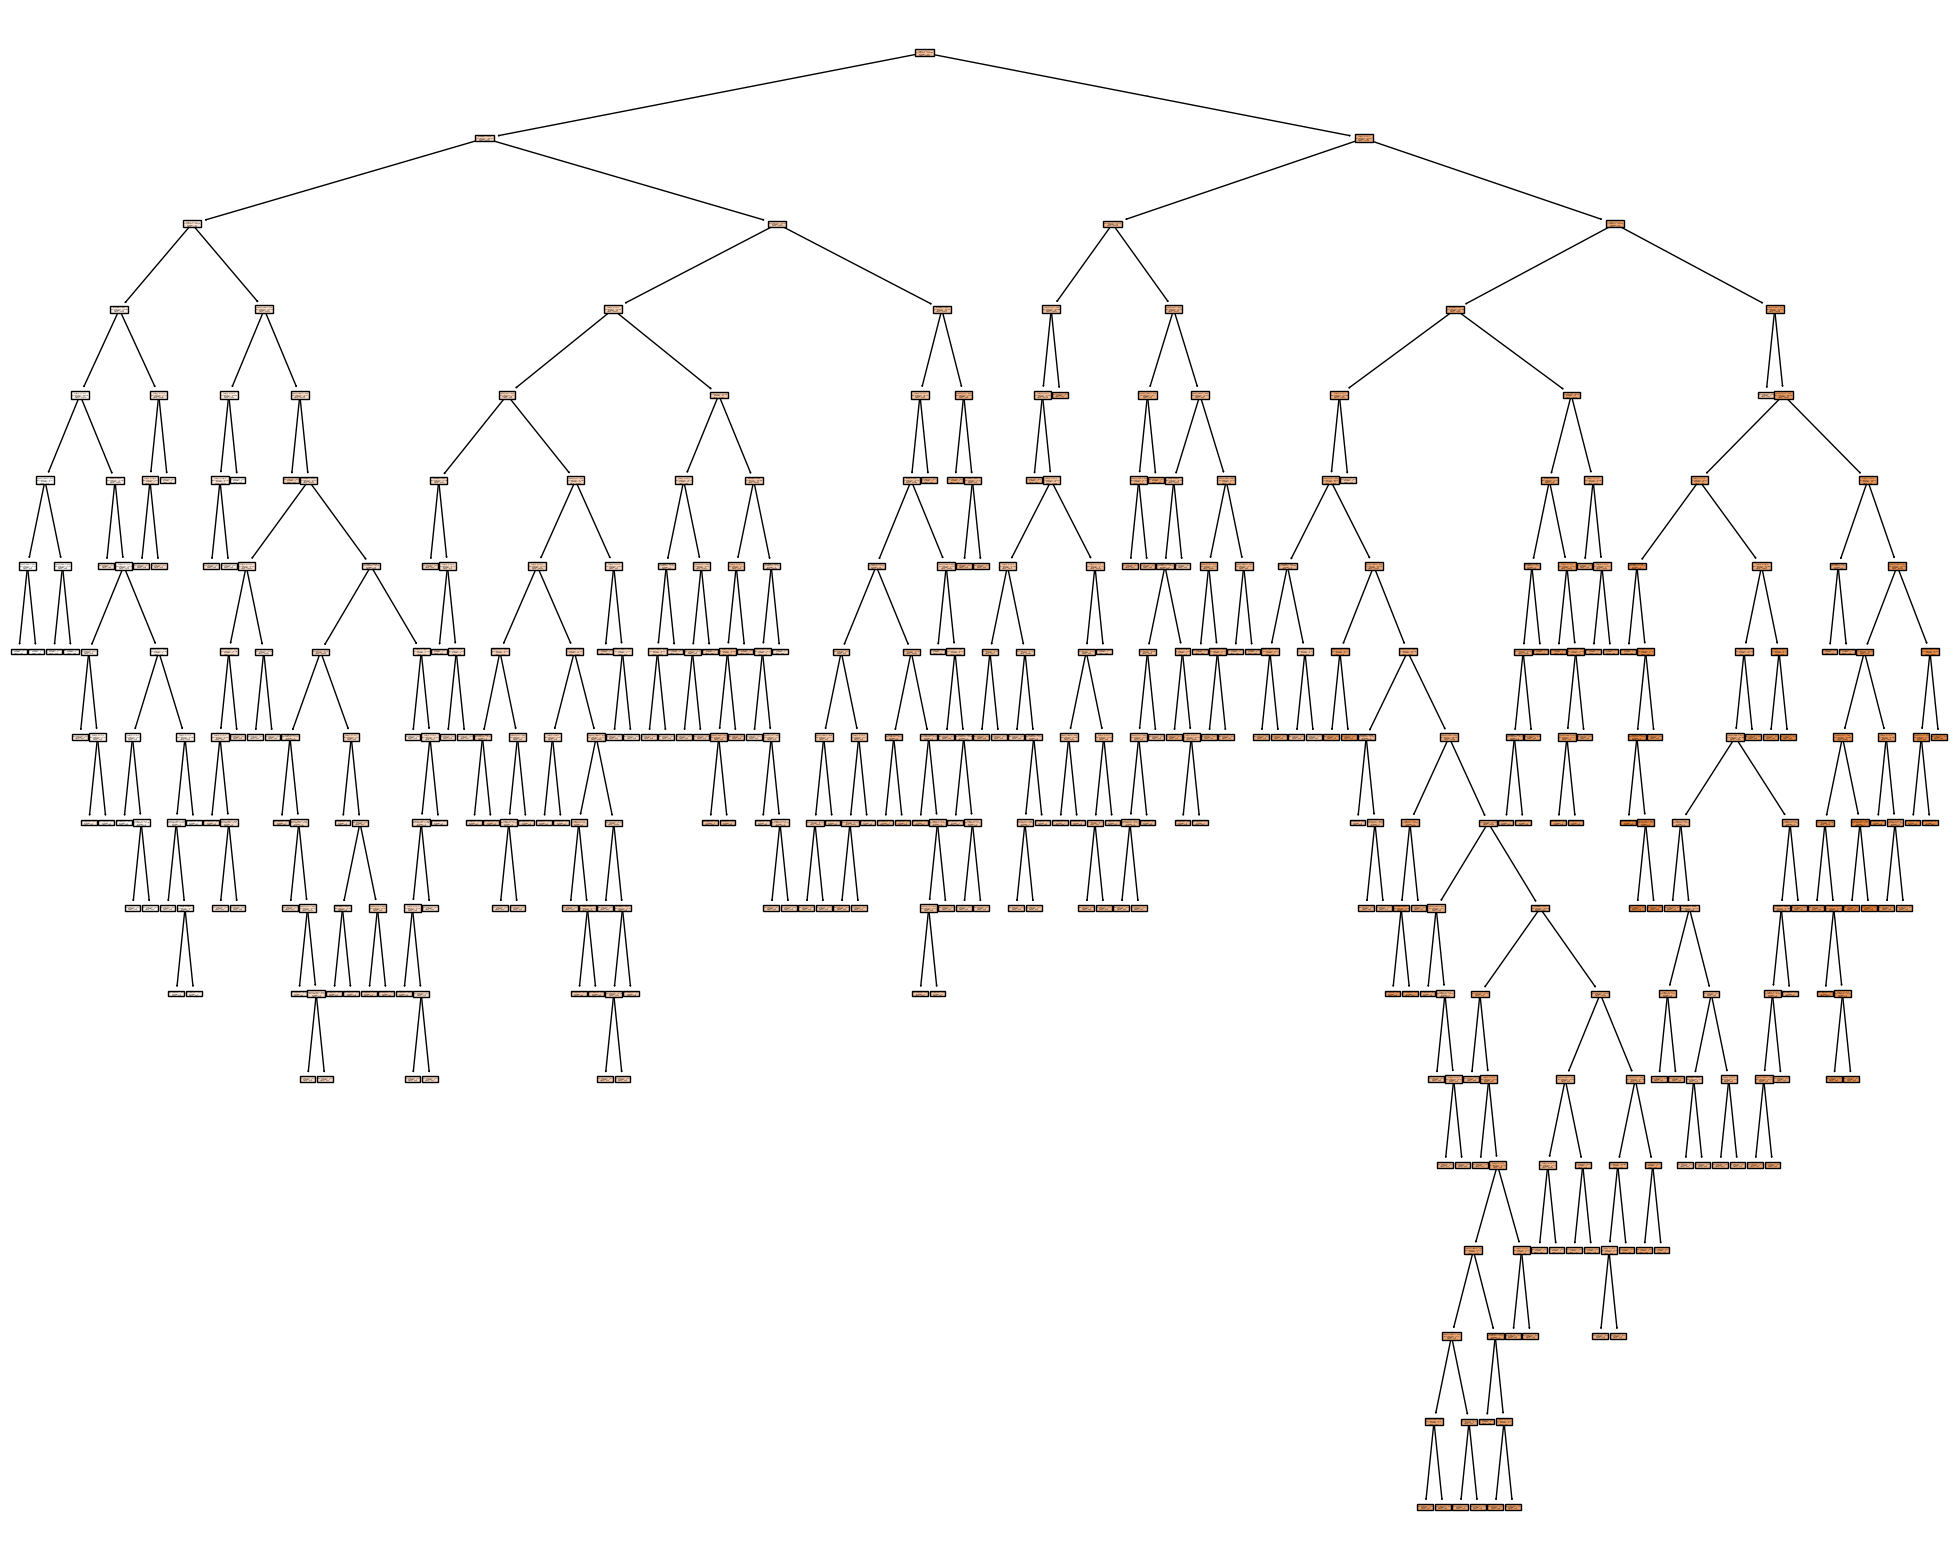

In [82]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(model,
                   feature_names=X_train.columns,
                   filled=True)

- Essa ãrvore tem mais de 15 níveis de profundidade, centenas de nós. Isso é exatamente o overfitting em forma visual.
- Uma árvore saudável teria 3 a 5 níveis — simples o suficiente para capturar padrões reais. Essa aqui cresceu sem limite, criando ramificações para casos raríssimos que provavelmente nunca se repetem em dados novos.


### Avaliar o melhor valor de max_depth

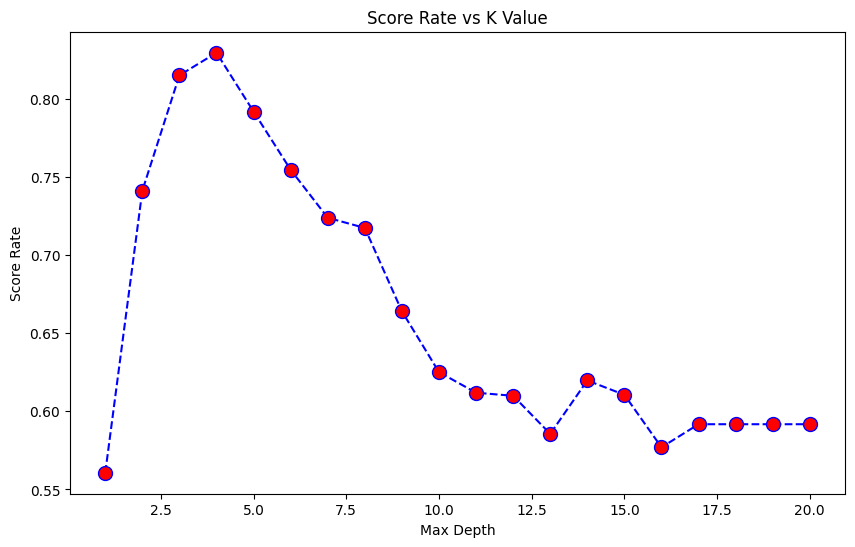

In [83]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

score = []

for i in range(1, 21): # Testa 20 versões diferentes da árvore
    reg = DecisionTreeRegressor(max_depth=i, random_state=111)
    reg.fit(X_train, y_train)
    score.append(reg.score(X_test, y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,21), score, color='blue', linestyle='dashed', marker='o', 
         markerfacecolor='red', markersize=10)
plt.title('Score Rate vs K Value')
plt.xlabel('Max Depth')
plt.ylabel('Score Rate')
plt.show()

- max_depth=1  → R²≈0.56  (muito simples, underfitting)
- max_depth=4  → R²≈0.83  ← PICO! Melhor resultado
- max_depth=5+ → score cai progressivamente (overfitting aumentando)
- max_depth=20 → R²≈0.59  (decorou os dados, não generaliza)

O melhor max_depth é 4, pois é onde o R² no teste é máximo (~0.83). Esse valor vamos usar na próxima célula para criar o modelo final otimizado — bem diferente do 0.66 que obtivemos sem restrição!

### Criar um regressor com o melhor valor para max_depth e avalie





In [84]:
reg_best = DecisionTreeRegressor(max_depth=score.index(max(score))+1) # vai pegar o index do melhor score e somar 1, pois o index começa em 0

reg_best.fit(X_train, y_train)
print('Train: ', reg_best.score(X_train, y_train))
print('Test: ',reg_best.score(X_test, y_test))

Train:  0.8770739780380298
Test:  0.8295978517092348


- Pega automaticamente o max_depth que gerou o maior score no loop anterior (que foi 4). O +1 existe porque o índice da lista começa em 0, mas o range começava em 1.
- A diferença entre treino e teste agora é pequena — o overfitting foi controlado.

In [85]:
print_metrics(y_test, reg_best.predict(X_test))

MEAN:  4.07075887826395
MAPE:  0.06695221574918843
MSE:  25.32042195398782
RMSE:  5.031940177902339
R²:  0.8295978517092348


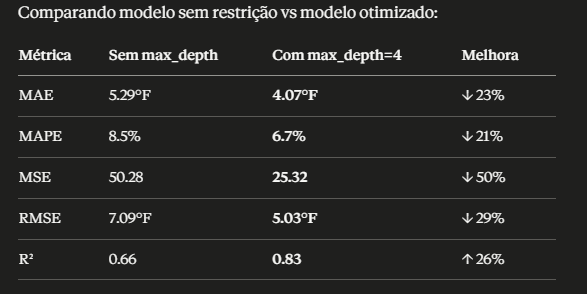

Resumo

Modelo simples (sem max_depth)

  → Treino: 1.00 / Teste: 0.66  ← overfitting grave
             
             ↓ ajuste com loop

Modelo otimizado (max_depth=4)

  → Treino: 0.87 / Teste: 0.83  ← equilibra

### Plot dos valores previstos vs reais

In [86]:
y_pred = reg_best.predict(X_test)

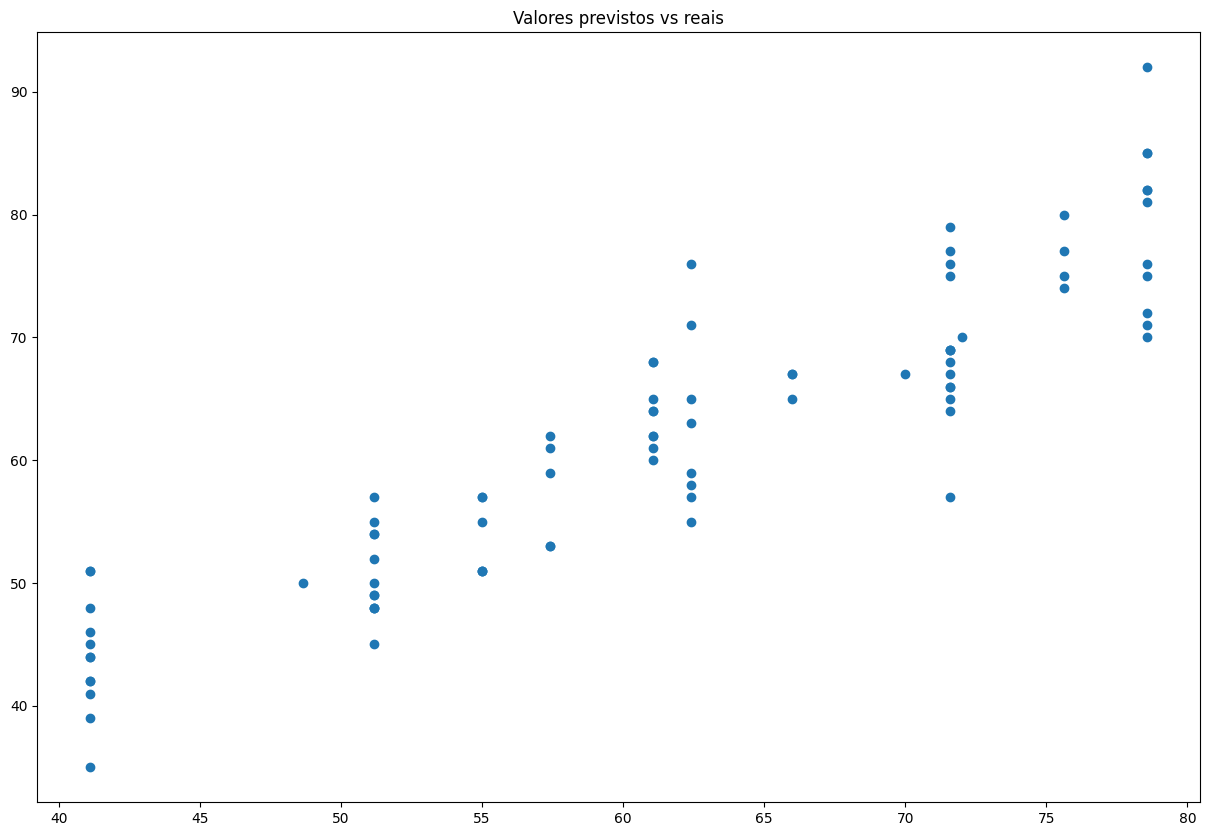

In [87]:
fig = plt.figure(figsize=(15,10))
plt.scatter(y_pred, y_test)
plt.title('Valores previstos vs reais')
plt.show()

Quanto mais os pontos formarem uma diagonal reta (↗), melhor o modelo. Se previsto = real, o ponto cai exatamente na diagonal.

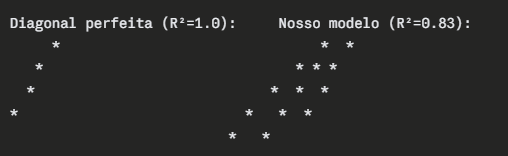

## Gráfico da árvore otimizada

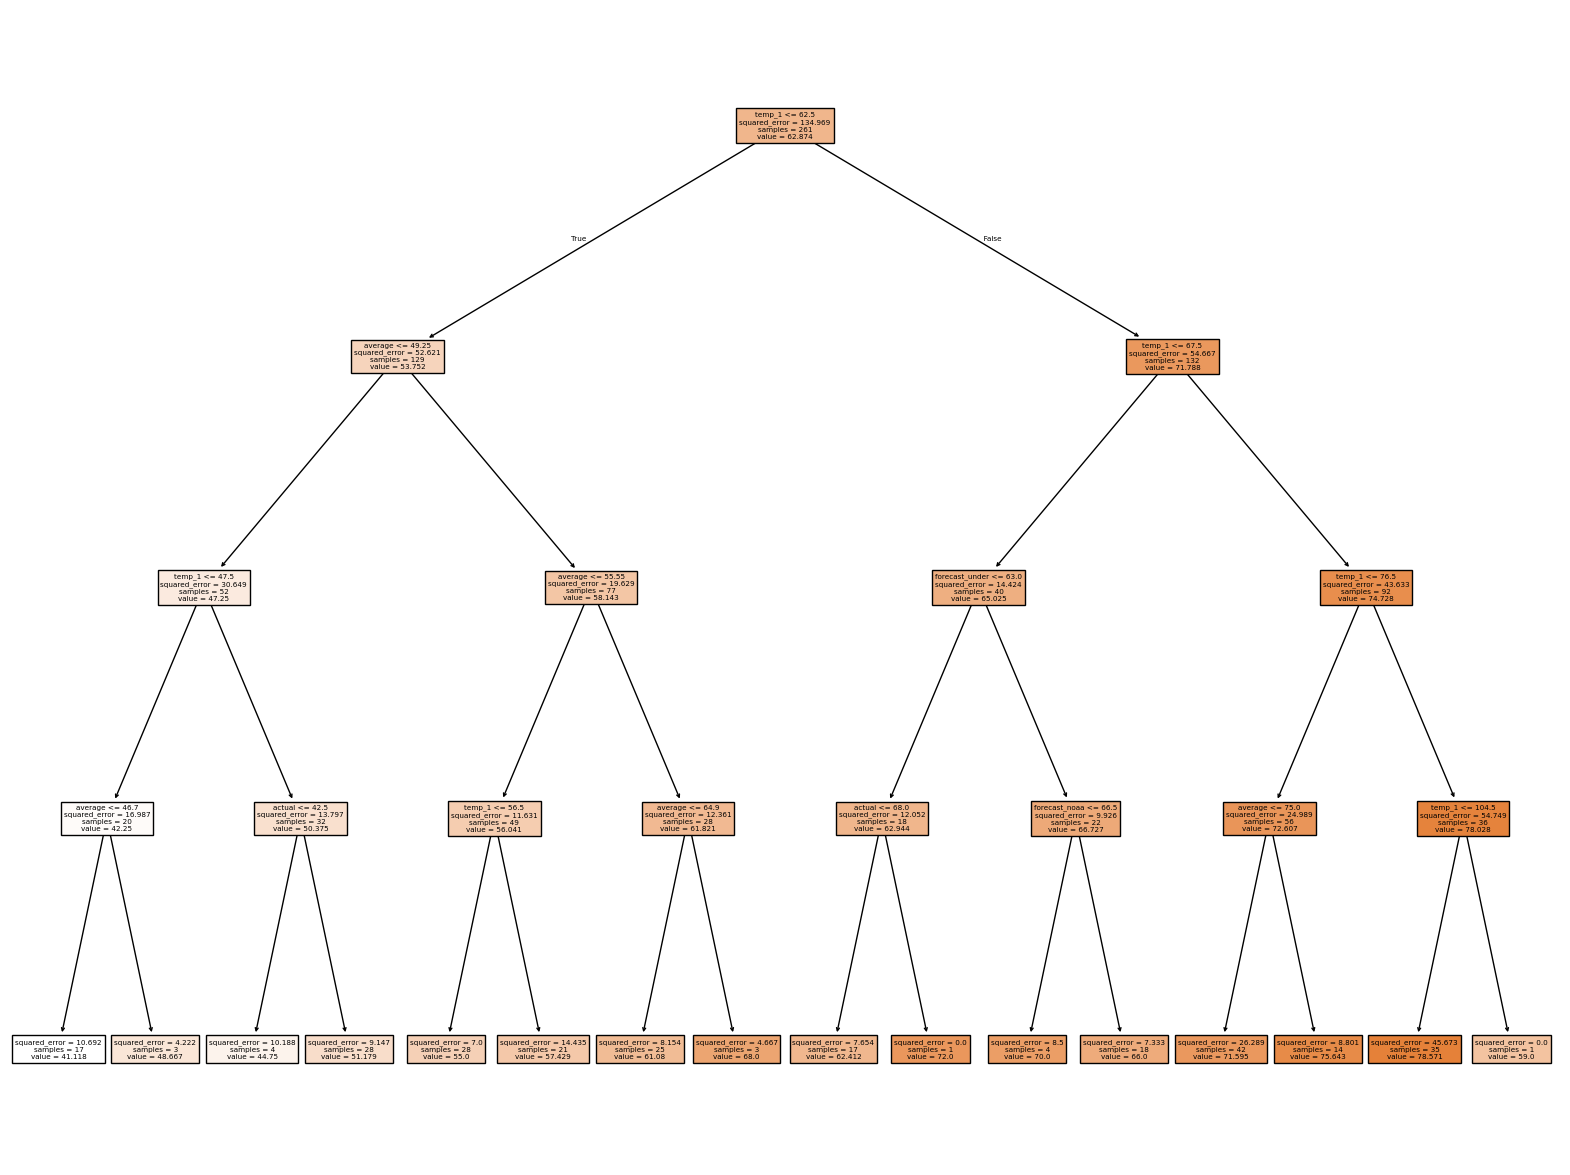

In [88]:
fig = plt.figure(figsize=(20,15))
plt.title('Melhor regressor')
_ = tree.plot_tree(reg_best,
                   feature_names=df.columns,
                   class_names=y_test.unique(),
                   filled=True)

A pergunta: "A temperatura de ontem foi ≤ 62.5°F?"

- True → vai para a esquerda (dias mais frios)

- False → vai para a direita (dias mais quentes)


Nível 2 — segunda pergunta:

- Esquerda: average <= 49.22 — usa a média histórica

- Direita: temp_1 <= 67.5 — usa 


Nível 3 — terceira pergunta:

- Aparecem variáveis como forecast_under, actual — a árvore vai refinando a previsão


Último nível

- squared_error = X.XX   ← erro nesse grupo
- samples = N            ← quantos dias caíram aqui
- value = XX.X           ← temperatura prevista

#### Essa árvore resume como o modelo realmente toma decisões — começa pela temperatura de ontem, refina com a média histórica, e chega a uma previsão clara em apenas 4 perguntas.

In [89]:
best_depth = score.index(max(score)) + 1
print(f"Melhor max_depth encontrado: {best_depth}")
print(f"Melhor score (R²): {max(score):.4f}")

Melhor max_depth encontrado: 4
Melhor score (R²): 0.8296


# Conclusão

Neste exercício, aplicamos o algoritmo de Árvore de Decisão para Regressão na previsão da temperatura máxima diária de Seattle.

O modelo inicial, sem nenhuma restrição de profundidade, memorizou os dados de treino (R² = 1.0), mas teve desempenho mediano no teste (R² = 0.66) — um caso claro de overfitting.

Ao testar diferentes valores de max_depth (de 1 a 20), identificamos que a profundidade 4 oferece o melhor equilíbrio: o modelo aprendeu os padrões reais sem decorar os dados, atingindo R² = 0.83 no teste e erro médio de apenas ~4°F.

A variável mais determinante para a previsão foi a temperatura do dia anterior (temp_1), aparecendo logo na raiz da árvore — o que faz sentido intuitivo: o melhor indicador da temperatura de amanhã é a de hoje.


Resumo:
- O modelo DecisionTreeRegressor sem restrição tende ao overfitting.
- Ao ajustar max_depth com o loop acima, encontramos a profundidade
- que maximiza o score R² no conjunto de teste.
- A validação cruzada (cv=5) confirma a estabilidade do modelo,
- reportando média e desvio padrão do R² sobre os 5 folds.
- O gráfico scatter (valores previstos vs reais) avalia visualmente
- a qualidade do regressor: pontos próximos à diagonal = bom ajuste.